In [9]:
from google.colab import files
import pandas as pd

# Tải lên tệp CSV
uploaded = files.upload()

# Đọc tệp CSV vào DataFrame sau khi tải lên
for filename in uploaded.keys():
  df = pd.read_csv(filename)
  print(f"Tệp '{filename}' đã được tải lên và đọc thành công.")
  display(df.head())
  break # Chỉ xử lý tệp đầu tiên nếu có nhiều tệp được tải lên

Saving facebook_reviews.csv to facebook_reviews.csv
Tệp 'facebook_reviews.csv' đã được tải lên và đọc thành công.


,reviewId,userName,content,score,thumbsUpCount,reviewCreatedVersion,at,appVersion
0,b290c064-f2af-4509-b425-0b6a1bca51a9,Angela Larsen,all these new updates are causing so many glit...,2,10,556.1.0.63.64,2026-04-20 04:01:19,556.1.0.63.64
1,b03e2730-8311-4dab-80e3-a6447013913d,Angelle Rivera,"Some post are missing, please fix the system. ...",1,3,556.1.0.63.64,2026-04-16 01:58:34,556.1.0.63.64
2,16db6557-41b3-470b-9cfd-b960fbb52bb8,Westerson Pakyntein,This is the worst app ever. I have changed my ...,1,4,555.0.0.49.59,2026-04-13 05:04:50,555.0.0.49.59
3,09ea8f0a-a833-439b-9323-224c101a41f0,Janet H Brasher,love Facebook. enjoy reading and seeing lots o...,2,1,555.0.0.49.59,2026-04-09 05:32:58,555.0.0.49.59
4,69629bec-26c0-4c1a-82c9-ab37e9c68a8b,Shawn Poirier,"everything is fine , just getting the hang of ...",5,5,554.0.0.57.70,2026-04-05 07:30:05,554.0.0.57.70


## 1. Data Preprocessing

Before training any machine learning model, we need to preprocess the text data. This typically involves:
1.  **Identifying Feature and Target Columns**: We'll assume a 'review_text' column for the input features and a 'sentiment' column for the target variable. Please adjust these if your CSV file uses different column names.
2.  **Handling Missing Values**: Basic check and removal if necessary.
3.  **Text Vectorization**: Converting text data into numerical features using techniques like TF-IDF (Term Frequency-Inverse Document Frequency).
4.  **Splitting Data**: Dividing the dataset into training and testing sets to evaluate model performance.

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import os

# --- Configuration ---
# Adjust these column names if they are different in your dataset
TEXT_COLUMN = 'content' # Updated to 'content' based on available columns
TARGET_COLUMN = 'score' # Updated to 'score' based on available columns

# Check if the DataFrame 'df' is available. If not, the user needs to re-run the upload cell.
if 'df' not in locals() and 'df' not in globals():
    raise NameError(
        "DataFrame 'df' not found. Please run the first code cell (cell `a6aaf6eb`) "
        "to upload your CSV file and define the 'df' DataFrame before proceeding."
    )

# Check if the assumed columns exist
if TEXT_COLUMN not in df.columns or TARGET_COLUMN not in df.columns:
    print(f"Error: Expected columns '{TEXT_COLUMN}' or '{TARGET_COLUMN}' not found in the DataFrame.")
    print("Please update TEXT_COLUMN and TARGET_COLUMN variables to match your dataset.")
    print("Available columns: ", df.columns.tolist())
else:
    # Drop rows with missing values in the relevant columns
    df.dropna(subset=[TEXT_COLUMN, TARGET_COLUMN], inplace=True)

    # Encode target labels if they are categorical (e.g., 'positive', 'negative')
    label_encoder = LabelEncoder()
    df['encoded_sentiment'] = label_encoder.fit_transform(df[TARGET_COLUMN])

    # Split data into features (X) and target (y)
    X = df[TEXT_COLUMN]
    y = df['encoded_sentiment']

    # Vectorize text data using TF-IDF
    vectorizer = TfidfVectorizer(max_features=5000) # You can adjust max_features
    X_vectorized = vectorizer.fit_transform(X)

    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(
        X_vectorized, y, test_size=0.2, random_state=42, stratify=y
    )

    print("Data preprocessing complete.")
    print(f"Training data shape: {X_train.shape}")
    print(f"Testing data shape: {X_test.shape}")
    print(f"Classes: {label_encoder.classes_}")
    print(f"Encoded classes: {label_encoder.transform(label_encoder.classes_)}")

Data preprocessing complete.
Training data shape: (284568, 5000)
Testing data shape: (71142, 5000)
Classes: [1 2 3 4 5]
Encoded classes: [0 1 2 3 4]


## 2. Machine Learning Model Implementation and Evaluation

Now we will implement and evaluate each of the requested machine learning models: Naive Bayes, Support Vector Machine (SVM), Logistic Regression, and Random Forest.

### 2.1 Naive Bayes Classifier

We'll use a Multinomial Naive Bayes classifier, which is commonly used for text classification tasks.

In [15]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score

# Initialize and train the Naive Bayes model
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_nb = nb_model.predict(X_test)

# Evaluate the model
print("--- Naive Bayes Classifier ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_nb):.4f}")
print("Classification Report:")
# Convert numerical class labels to strings for the classification report
print(classification_report(y_test, y_pred_nb, target_names=[str(c) for c in label_encoder.classes_]))

--- Naive Bayes Classifier ---
Accuracy: 0.7260
Classification Report:
              precision    recall  f1-score   support

           1       0.61      0.67      0.64     13856
           2       0.50      0.00      0.00      3294
           3       0.21      0.00      0.01      3970
           4       0.26      0.01      0.01      5388
           5       0.76      0.95      0.84     44634

    accuracy                           0.73     71142
   macro avg       0.47      0.33      0.30     71142
weighted avg       0.65      0.73      0.66     71142



### 2.2 Support Vector Machine (SVM)

SVMs are powerful and effective for classification tasks, often performing well with high-dimensional data like text features.

In [17]:
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score # Added accuracy_score for consistency if not imported earlier

# Initialize and train the Linear SVM model
# LinearSVC is often preferred for large datasets over SVC with a linear kernel
svm_model = LinearSVC(random_state=42)
svm_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_svm = svm_model.predict(X_test)

# Evaluate the model
print("--- Support Vector Machine (LinearSVC) ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}")
print("Classification Report:")
# Convert numerical class labels to strings for the classification report
print(classification_report(y_test, y_pred_svm, target_names=[str(c) for c in label_encoder.classes_]))

--- Support Vector Machine (LinearSVC) ---
Accuracy: 0.7386
Classification Report:
              precision    recall  f1-score   support

           1       0.68      0.66      0.67     13856
           2       0.20      0.01      0.02      3294
           3       0.22      0.01      0.02      3970
           4       0.28      0.01      0.01      5388
           5       0.76      0.97      0.85     44634

    accuracy                           0.74     71142
   macro avg       0.43      0.33      0.31     71142
weighted avg       0.65      0.74      0.67     71142



### 2.3 Logistic Regression

Despite its name, Logistic Regression is a widely used linear model for binary and multiclass classification.

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score # Added for consistency

# Initialize and train the Logistic Regression model
# 'saga' solver is good for large datasets and handles L1/L2 regularization
# max_iter can be increased if convergence warnings occur
lr_model = LogisticRegression(random_state=42, solver='saga', max_iter=1000)
lr_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_lr = lr_model.predict(X_test)

# Evaluate the model
print("--- Logistic Regression ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print("Classification Report:")
# Convert numerical class labels to strings for the classification report
print(classification_report(y_test, y_pred_lr, target_names=[str(c) for c in label_encoder.classes_]))

--- Logistic Regression ---
Accuracy: 0.7400
Classification Report:
              precision    recall  f1-score   support

           1       0.68      0.66      0.67     13856
           2       0.31      0.01      0.02      3294
           3       0.25      0.01      0.03      3970
           4       0.30      0.01      0.02      5388
           5       0.76      0.97      0.85     44634

    accuracy                           0.74     71142
   macro avg       0.46      0.33      0.32     71142
weighted avg       0.66      0.74      0.67     71142



### 2.4 Random Forest Classifier

Random Forest is an ensemble learning method that builds multiple decision trees and merges them to get a more accurate and stable prediction.

In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score # Added for consistency

# Initialize and train the Random Forest model
# n_estimators can be tuned for better performance
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1) # n_jobs=-1 uses all available cores
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
print("--- Random Forest Classifier ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print("Classification Report:")
# Convert numerical class labels to strings for the classification report
print(classification_report(y_test, y_pred_rf, target_names=[str(c) for c in label_encoder.classes_]))

--- Random Forest Classifier ---
Accuracy: 0.7325
Classification Report:
              precision    recall  f1-score   support

           1       0.64      0.67      0.66     13856
           2       0.22      0.02      0.03      3294
           3       0.24      0.02      0.04      3970
           4       0.30      0.02      0.04      5388
           5       0.76      0.95      0.85     44634

    accuracy                           0.73     71142
   macro avg       0.43      0.34      0.32     71142
weighted avg       0.65      0.73      0.67     71142



## 4. Compare Model Performance

Let's visualize the accuracy of each model using a bar chart for easy comparison.

/tmp/ipykernel_12236/3824381691.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Accuracy', y='Model', data=accuracy_df, palette='viridis')


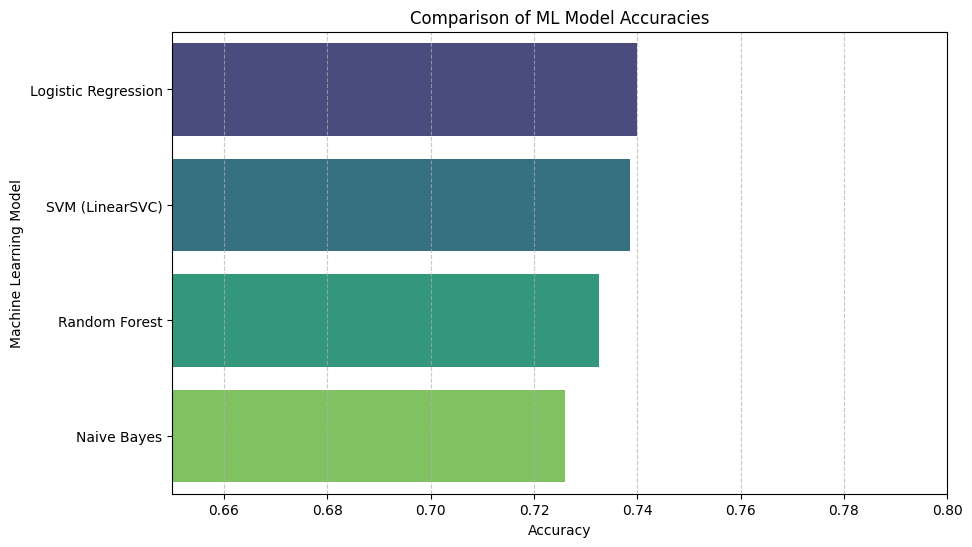

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Collect accuracy scores from each model
model_accuracies = {
    'Naive Bayes': accuracy_score(y_test, y_pred_nb),
    'SVM (LinearSVC)': accuracy_score(y_test, y_pred_svm),
    'Logistic Regression': accuracy_score(y_test, y_pred_lr),
    'Random Forest': accuracy_score(y_test, y_pred_rf)
}

# Create a DataFrame for easy plotting
accuracy_df = pd.DataFrame(model_accuracies.items(), columns=['Model', 'Accuracy'])

# Sort by accuracy for better visualization
accuracy_df = accuracy_df.sort_values(by='Accuracy', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Accuracy', y='Model', data=accuracy_df, palette='viridis')
plt.title('Comparison of ML Model Accuracies')
plt.xlabel('Accuracy')
plt.ylabel('Machine Learning Model')
plt.xlim(0.65, 0.8) # Set appropriate limits based on typical accuracy ranges
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()


## 3. Suggestions for Similar ML Models

Here are some other machine learning models that are commonly used for classification tasks, especially with text data:

*   **Gradient Boosting Machines (GBM)**: Algorithms like XGBoost, LightGBM, and CatBoost are highly efficient and effective, often achieving state-of-the-art results in structured data and can also be applied to text features.
*   **Neural Networks (Deep Learning)**: For more complex text classification tasks, deep learning models can be very powerful:
    *   **Recurrent Neural Networks (RNNs)**: Specifically LSTMs (Long Short-Term Memory) or GRUs (Gated Recurrent Units) are good for sequential data like text.
    *   **Convolutional Neural Networks (CNNs)**: Can be used for text classification by treating text as a 1D sequence.
    *   **Transformer-based Models**: Models like BERT, RoBERTa, XLNet, or specialized models like DistilBERT, if you have sufficient computational resources and data, offer excellent performance by capturing contextual relationships in text.
*   **K-Nearest Neighbors (KNN)**: A simple non-parametric algorithm that classifies a data point based on the majority class of its 'k' nearest neighbors. Less common for high-dimensional text data but can be used.
*   **Decision Trees**: The base learners for Random Forests. While a single decision tree can be prone to overfitting, they are interpretable.
*   **Ensemble Methods (beyond Random Forest)**: Beyond Random Forests, consider other ensemble techniques like Bagging Classifiers or Voting Classifiers (combining predictions from multiple different models).